<a href="https://colab.research.google.com/github/8Dis-like/UCLALearning/blob/main/CS260R_assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3: Reinforcement Learning Pipeline in Practice


*CS260R: Reinforcement Learning. Department of Computer Science at University of California, Los Angeles.
Course Instructor: Professor Bolei ZHOU. Assignment author: Zhenghao PENG.*

-----


## TODOs

You need to implement all TODOs in the python files. Then run all cells in this notebook and plot your results.

Note:

1. You can run the training in your terminal and selectively run the visualization and evaluation cells in this notebook.
2. You need to remove the "REFERENCE" in figures.
3. You don't need to exactly reproduce our results, but your implementation should show the similar progress in training.
4. We use multi-processing to enable asynchronous data sampling. Therefore in many places the tensors have shape `[num_steps, num_envs, num_feat]`. This means that `num_envs` environments are running concurrently and each of them samples a fragment of trajectory with length `num_steps`. There are totally `num_steps*num_envs` transitions are generated in each training iteration.
5. Each process can only have a single MetaDrive environment.
6. The jupyter notebook is used for tutorial and visualization. It is optional for you to use the notebook to call `train_ppo|td3.py` and `eval_ppo|td3.py`. But we expect to see figures, results and visualization in this notebook.




We are expecting the following figures, results and visualization:

1. TD3 in Pendulum-v1: learning curve (2.1)
2. TD3 in MetaDrive-Tut-Hard-v0: learning curve (2.2), evaluation result (2.3)
3. PPO in CartPole-v1: learning curve (3.1)
4. PPO in MetaDrive-Tut-Hard-v0: learning curve (3.2), evaluation result (3.3), visualization (3.4)


### File structure

You need to pay attention to the files below:

TD3:

* `core/td3_trainer.py` - File which can be directly run to train TD3. **Please implement TD3 here.**

PPO:

* `train_ppo.py` - Train scripts for PPO in CartPole-v0 and MetaDrive. **Please implement TODO in this file.**
* `core/ppo_trainer.py` - PPO algorithm. **Please implement `compute_action` and `compute_loss`.**
* `core/buffer.py` - Supporting data structure for PPO (GAE is implemented here). **Please implement `compute_returns` for PPO.**

Common:

* `assignment3.ipynb` - Useful jupyter notebook to walk you through the whole assignment. You need to plot figures and results here.
* `[train|eval]_[ppo|td3].py` - The entries to training and evaluation.


### Deliverables

1) The exported **PDF file** of the this notebook.
2) Compress all files in the `assignment3` folder and prepare a **ZIP file**. No `.rar` or other format is allowed.

You need to submit **both the ZIP file and the PDF file** to bruinlearn. The PDF file goes to gradescope tab and the
ZIP file goes to the assignment tab.



### Colab supporting

Though we use multiple files to implement algorithms, we can still leverage Colab for free computing resources.

* Step 1: Create a folder in your Google Drive root named `cs260r`
* Step 2: Upload the files in `assignment3` folder such as `train_ppo.py` and the folder `core` to the newly created `cs260r` folder in your Google Drive.
* Step 3: Run the last cell in Demo 1 (pay attention to the code we mount the colab to your google drive).




## Demo 1: Setup dependencies

In [ ]:
!pip install torch

# Install MetaDrive, a lightweight driving simulator
!pip install git+https://github.com/metadriverse/metadrive

# Test whether MetaDrive is properly installed. No error means the test is passed.
!python -m metadrive.examples.profile_metadrive --num-steps 100

!pip install pandas scipy seaborn tabulate pyyaml

  Cloning https://github.com/metadriverse/metadrive to /tmp/pip-req-build-crrsvy7a
  Running command git clone --filter=blob:none --quiet https://github.com/metadriverse/metadrive /tmp/pip-req-build-crrsvy7a
  Resolved https://github.com/metadriverse/metadrive to commit 85e5dadc6c7436d324348f6e3d8f8e680c06b4db
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 92.1 MB/s eta 0:00:00
  Created wheel for metadrive-simulator: filename=metadrive_simulator-0.4.3-py3-none-any.whl size=55042153 sha256=9795db3272d1a51fea63641b122f27f36b323b6f7657bb698507ee3477fe4147
  Stored in directory: /tmp/pip-e

In [ ]:
import os

try:
    from google.colab import drive
    drive.mount('/content/gdrive')

    DRIVE_PATH = '/content/gdrive/My Drive/cs260r'  # No need for backslash
    if not os.path.exists(DRIVE_PATH):
        !mkdir -p "$DRIVE_PATH"  # Ensure the folder exists

    # Create a symlink to avoid issues with spaces in 'My Drive'
    SYM_PATH = '/content/cs260r'
    if not os.path.exists(SYM_PATH):
        !ln -s "$DRIVE_PATH" "$SYM_PATH"

    running_in_colab = True

    # We already mounted in our google drive.
    # Enter the foler where you put files in:
    %cd '/content/cs260r'

except ModuleNotFoundError:
    running_in_colab = False
    print("I guess you are running locally. If you get this message in Colab, something is wrong.")

print("\nCurrent working directory:")
!pwd

print("\nWhat files are there:")
!ls

Mounted at /content/gdrive
/content/gdrive/My Drive/cs260r

Current working directory:
/content/gdrive/My Drive/cs260r

What files are there:
assignment3.ipynb  format.sh		   pendulum-td3.png  train_td3.py
core		   __init__.py		   Pendulum-v1	     vis.py
eval_ppo.py	   metadrive-hard-td3.png  README.md
eval_td3.py	   MetaDrive-Tut-Hard-v0   train_ppo.py


## Demo 2: Train a TD3 agent

Spinning Up tutorial provides great explaination on TD3 algorithm:
https://spinningup.openai.com/en/latest/algorithms/td3.html

Please implement all TODOs in `core/td3_trainer.py` and `train_td3.py`.

### Demo 2.1: Train TD3 agent in Pendulum-v1

In [ ]:
!python train_td3.py \
--env-id Pendulum-v1 \
--log-dir Pendulum-v1 \
--max-steps 50000 \
--start-steps 1000 \
--lr 1e-3

/content/gdrive/My Drive/cs260r/core
Training Step:   2% 772/50000 [00:00<00:06, 7714.82it/s]
 ===== TD3 Training Step 1199 =====:
  actor_loss: 8.652921676635742
  critic_loss: 0.6781964302062988
  current_q1: -8.832694053649902
  current_q2: -8.817402839660645
  episode_reward: -1257.2766673844405
  frame_per_second: 353
  log_dir: Pendulum-v1
  reward: -6.4789910316467285
  target_q: -8.922115325927734
  total_episodes: 6
  total_steps: 1199
  total_time: 3.395418882369995

Training Step:   4% 1868/50000 [00:14<08:00, 100.09it/s]Trainer is saved at <Pendulum-v1/td3>. Progress is saved at <Pendulum-v1/td3/progress.csv>.
Training Step:   4% 2157/50000 [00:19<09:38, 82.77it/s]
 ===== TD3 Training Step 2199 =====:
  actor_loss: 23.95347785949707
  critic_loss: 2.7780327796936035
  current_q1: -24.07634162902832
  current_q2: -24.109777450561523
  episode_reward: -1427.1124935456537
  frame_per_second: 105
  log_dir: Pendulum-v1
  reward: -7.251079559326172
  target_q: -24.11366653442382

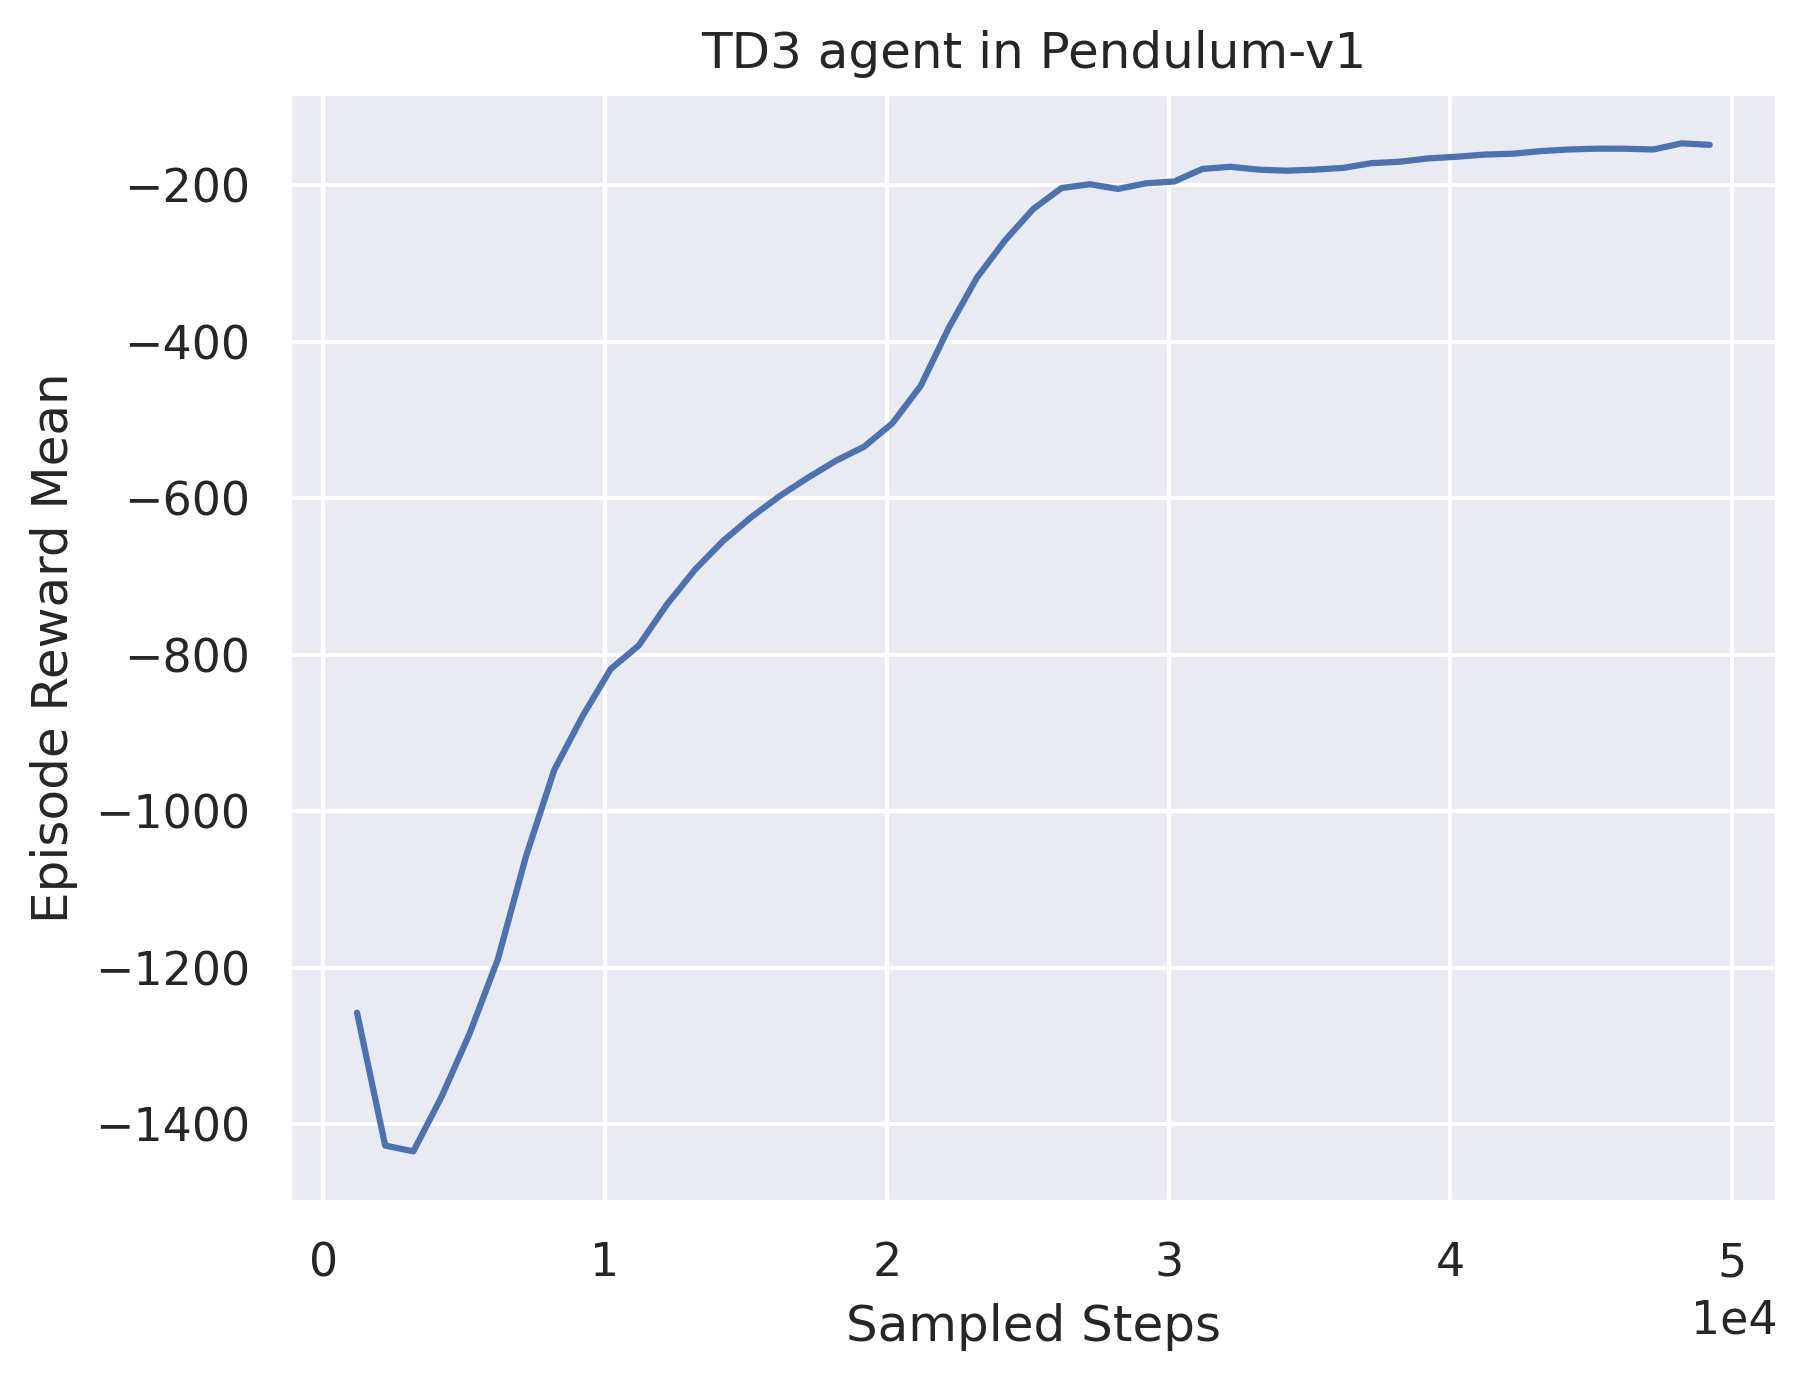

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

progress = pd.read_csv("Pendulum-v1/td3/progress.csv")
plt.figure(dpi=300)
sns.set("notebook", "darkgrid")
ax = sns.lineplot(
    data=progress,
    x="total_steps",
    y="episode_reward"
)
ax.set_title("TD3 agent in Pendulum-v1")
ax.set_ylabel("Episode Reward Mean")
ax.set_xlabel("Sampled Steps")

ax.ticklabel_format(style='sci', scilimits=(0,0), axis='x')

plt.savefig('pendulum-td3.png', format='png', dpi=300, bbox_inches="tight")


### Demo 2.2: Train TD3 agent in MetaDrive-Tut-Hard-v0


In [ ]:
!python train_td3.py \
--env-id MetaDrive-Tut-Hard-v0 \
--log-dir MetaDrive-Tut-Hard-v0 \
--max-steps 100_000


/content/gdrive/My Drive/cs260r/core
Successfully registered MetaDrive environments:  ['MetaDrive-Tut-Easy-v0', 'MetaDrive-Tut-Hard-v0', 'MetaDrive-Tut-1Env-v0', 'MetaDrive-Tut-5Env-v0', 'MetaDrive-Tut-10Env-v0', 'MetaDrive-Tut-20Env-v0', 'MetaDrive-Tut-50Env-v0', 'MetaDrive-Tut-100Env-v0', 'MetaDrive-Tut-Test-v0']
[INFO] Environment: MetaDriveEnv
[INFO] MetaDrive version: 0.4.3
[INFO] Sensors: [lidar: Lidar(), side_detector: SideDetector(), lane_line_detector: LaneLineDetector()]
[INFO] Render Mode: none
[INFO] Horizon (Max steps per agent): 1000
[INFO] Assets version: 0.4.3
[INFO] Known Pipes: glxGraphicsPipe
[INFO] Start Scenario Index: 1000, Num Scenarios : 20
Training Step:   2% 1688/100000 [00:08<10:57, 149.43it/s]
 ===== TD3 Training Step 1690 =====:
  actor_loss: .nan
  critic_loss: .nan
  episode_reward: 3.640690792773802
  frame_per_second: 191
  log_dir: MetaDrive-Tut-Hard-v0
  success_rate: 0.0
  target_q: .nan
  total_episodes: 2
  total_steps: 1690
  total_time: 8.8106765

The log contains these keys:  Index(['Unnamed: 0', 'log_dir', 'frame_per_second', 'episode_reward',
       'total_steps', 'total_episodes', 'total_time', 'target_q', 'actor_loss',
       'critic_loss', 'success_rate', 'current_q1', 'current_q2', 'reward'],
      dtype='object')


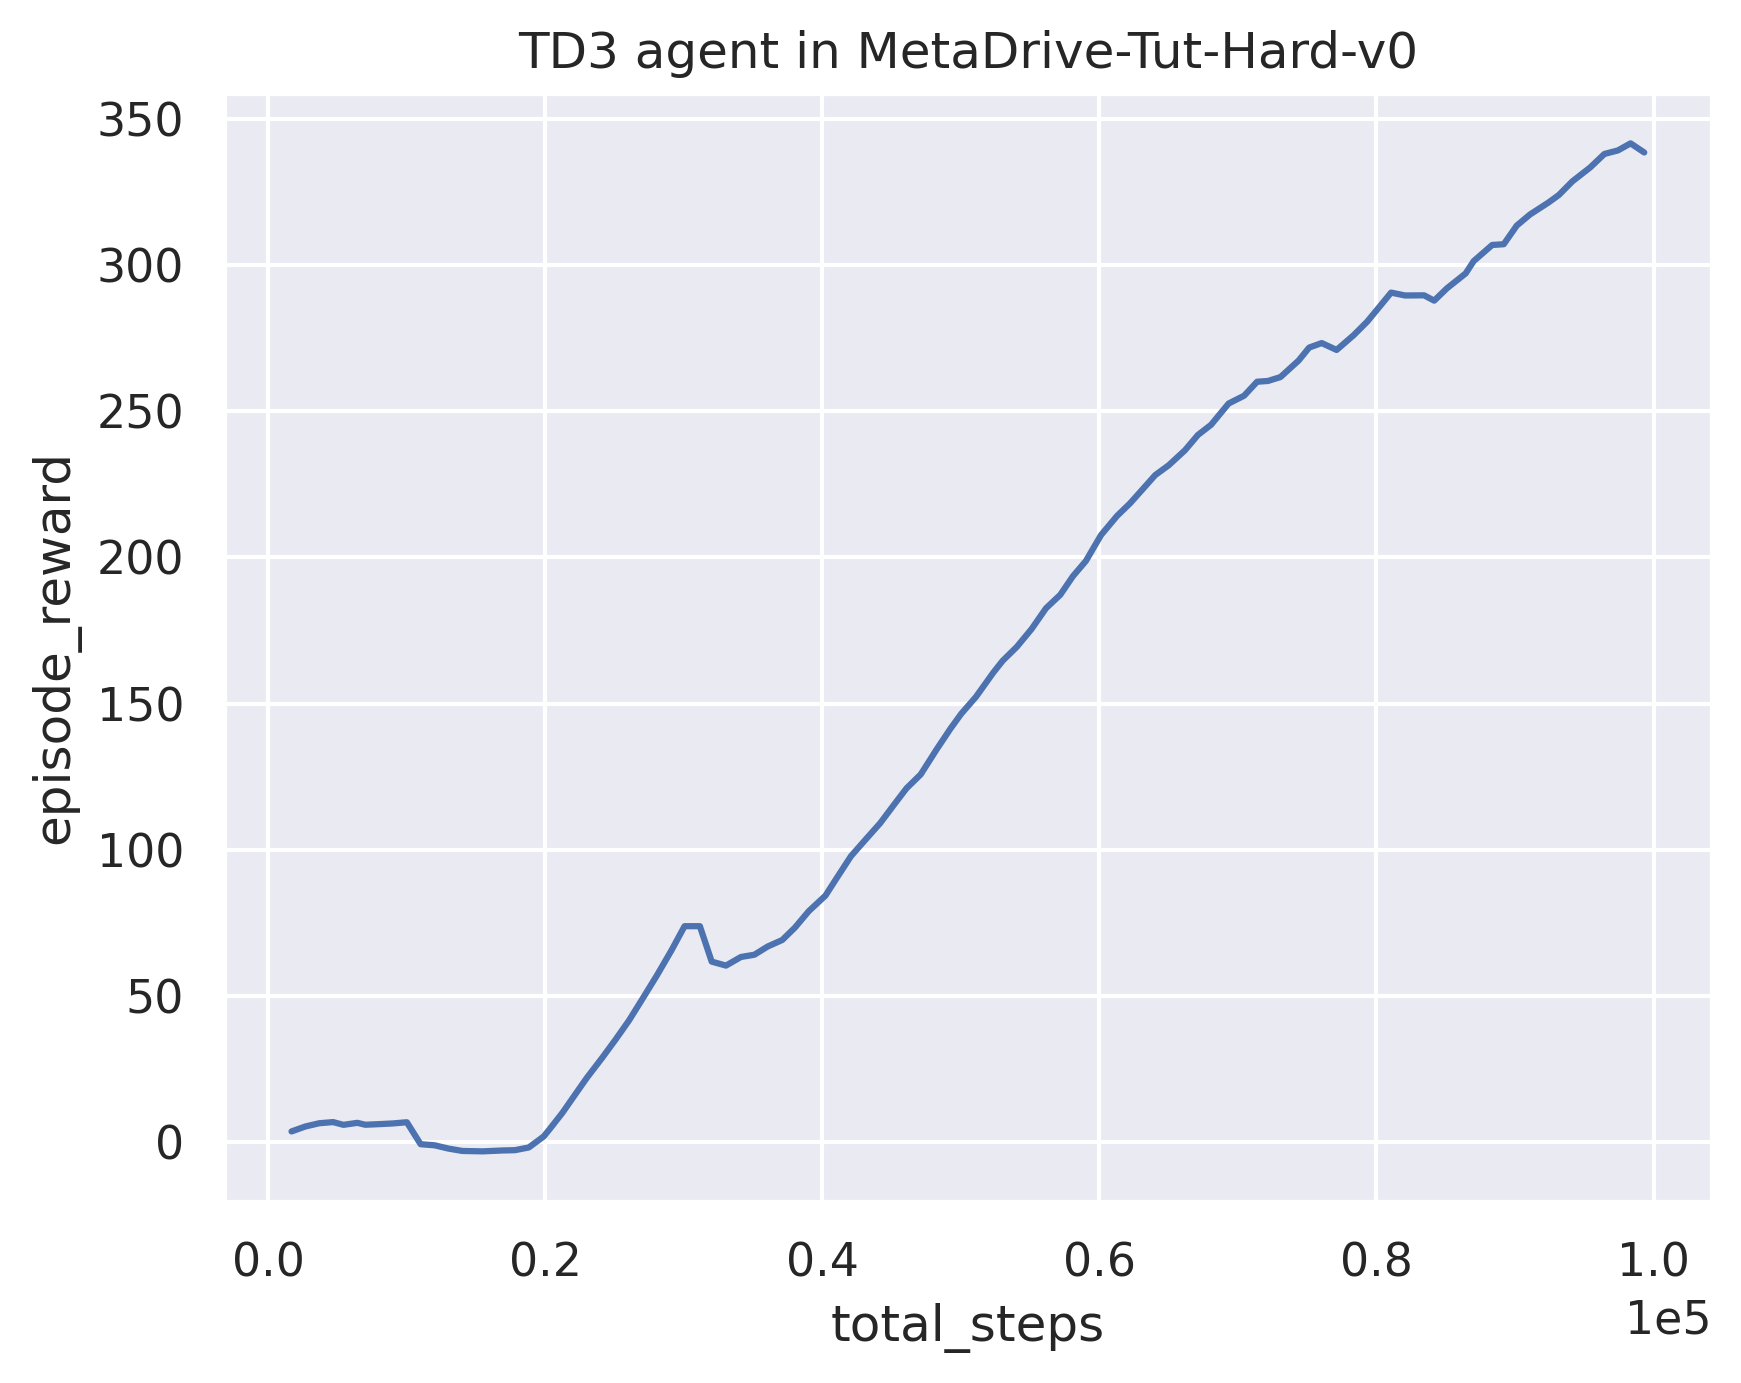

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

progress = pd.read_csv("MetaDrive-Tut-Hard-v0/td3/progress.csv")
print("The log contains these keys: ", progress.keys())
plt.figure(dpi=300)
sns.set("notebook", "darkgrid")
ax = sns.lineplot(
    data=progress,
    x="total_steps",
    y="episode_reward"
)
ax.set_title("TD3 agent in MetaDrive-Tut-Hard-v0")

ax.ticklabel_format(style='sci', scilimits=(0,0), axis='x')

plt.savefig('metadrive-hard-td3.png', format='png', dpi=300, bbox_inches="tight")


### Demo 2.3: Evaluate TD3 in MetaDrive

In [ ]:
!python eval_td3.py \
--env-id="MetaDrive-Tut-Hard-v0" \
--log-dir="MetaDrive-Tut-Hard-v0/td3"


/content/gdrive/MyDrive/cs260r/core
/content/gdrive/MyDrive/cs260r/core
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
Successfully registered MetaDrive environments:  ['MetaDrive-Tut-Easy-v0', 'MetaDrive-Tut-Hard-v0', 'MetaDrive-Tut-1Env-v0', 'MetaDrive-Tut-5Env-v0', 'MetaDrive-Tut-10Env-v0', 'MetaDrive-Tut-20Env-v0', 'MetaDrive-Tut-50Env-v0', 'MetaDrive-Tut-100Env-v0', 'MetaDrive-Tut-Test-v0']
/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment MetaDrive-Tut-Easy-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment MetaDrive-Tut-Hard-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

td3_eval = pd.read_csv("MetaDrive-Tut-Hard-v0/td3/eval_results.csv")
print("TD3 agent average reward: {}".format(td3_eval.rewards.mean()))

TD3 agent average reward: 274.14725140511905


## Demo 3: Train a PPO agent

You need to finish `core/ppo_trainer.py`, `core/buffer.py` and `train_ppo.py`.

Here we use GAE [1] (Generalized Advantage Estimation) to estimate the advantage. This technique is implemented in `PPORolloutStorage.compute_returns` in `core/buffer.py`. Concretely, we estimate the advantage of current state $t$ via:

$$\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$$

$$A^{GAE}_t = \sum_{l=0}^{\infty} (\gamma \lambda) ^ l \delta_{t+l}$$

wherein $V$ is the state value function, $\lambda$ is a hyper-parameter defined in `PPOConfig["gae_lambda"]`.

You can find that when $\lambda = 0$, the GAE estimates advantage in an one-step TD manner. When $\lambda = 1$, the GAE reduces to Monte Carlo Estimation of the state value. Therefore by varying the $\lambda$, we can adjust the trade-off between the accuracy of the estimation, namely the bias, and the variance of the advantage.

[1]: Schulman, John , et al. "High-Dimensional Continuous Control Using Generalized Advantage Estimation." (2015).

### Demo 3.1 Train and draw the learning curve of PPO in CartPole

In [ ]:
!python train_ppo.py \
--env-id CartPole-v1 \
--log-dir CartPole-v1 \
--num-envs 10 \
--max-steps 300000

/content/gdrive/My Drive/cs260r/core
Start training!
/content/gdrive/My Drive/cs260r/core
/content/gdrive/My Drive/cs260r/core
/content/gdrive/My Drive/cs260r/core
/content/gdrive/My Drive/cs260r/core
/content/gdrive/My Drive/cs260r/core
/content/gdrive/My Drive/cs260r/core
/content/gdrive/My Drive/cs260r/core
/content/gdrive/My Drive/cs260r/core
/content/gdrive/My Drive/cs260r/core
/content/gdrive/My Drive/cs260r/core
  0% 0/300000 [00:00<?, ?it/s]
 ===== ppo Training Iteration 0 =====:
  adv_mean: 8.715582847595215
  entropy: 0.6853045637790973
  episode_reward: 23.07
  frame_per_second: 1046
  grad_norm: 19.970492362976074
  iteration: 0
  log_dir: /content/gdrive/My Drive/cs260r/CartPole-v1/ppo
  policy_loss: -0.017992512193412927
  ratio: 1.0012673840308801
  total_episodes: 858
  total_loss: 31.252865030826666
  total_steps: 20000
  total_time: 19.109383821487427
  value_loss: 31.270857586004794

Trainer is saved at </content/gdrive/My Drive/cs260r/CartPole-v1/ppo/checkpoint-iter

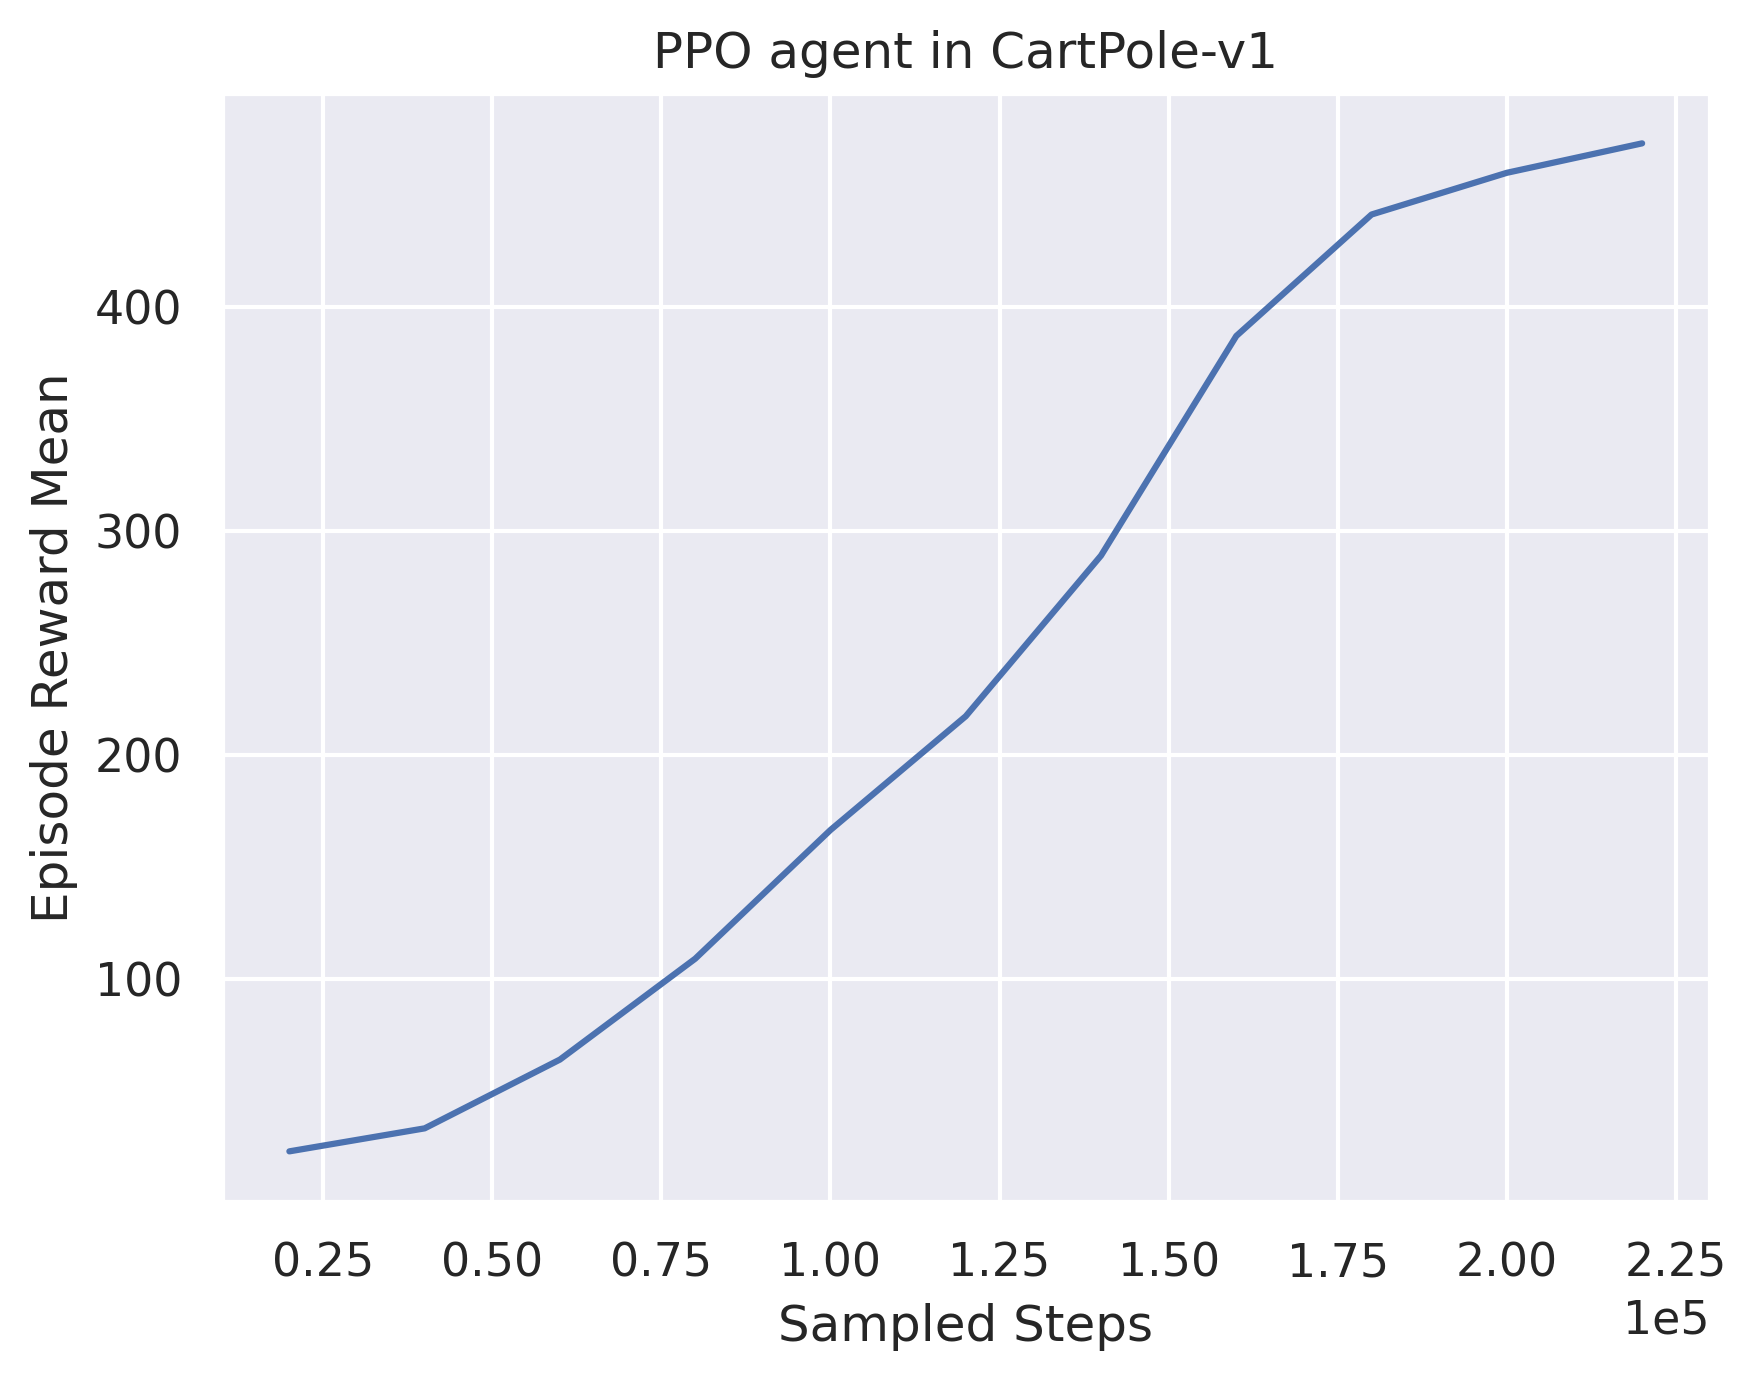

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ppo_progress = pd.read_csv("CartPole-v1/ppo/progress.csv")
plt.figure(dpi=300)
sns.set("notebook", "darkgrid")
ax = sns.lineplot(
    data=ppo_progress,
    x="total_steps",
    y="episode_reward"
)
ax.set_title("PPO agent in CartPole-v1")
ax.set_ylabel("Episode Reward Mean")
ax.set_xlabel("Sampled Steps")

ax.ticklabel_format(style='sci', scilimits=(0,0), axis='x')

plt.savefig('cartpole-ppo.png', format='png', dpi=300, bbox_inches="tight")


### Demo 3.2: Train and play with the PPO agent in MetaDrive Hard Env.

In [ ]:
!python train_ppo.py \
  --env-id MetaDrive-Tut-Hard-v0 \
  --log-dir MetaDrive-Tut-Hard-v0 \
  --num-envs 10 \
  --max-steps 1_000_000

/content/gdrive/My Drive/cs260r/core
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
Successfully registered MetaDrive environments:  ['MetaDrive-Tut-Easy-v0', 'MetaDrive-Tut-Hard-v0', 'MetaDrive-Tut-1Env-v0', 'MetaDrive-Tut-5Env-v0', 'MetaDrive-Tut-10Env-v0', 'MetaDrive-Tut-20Env-v0', 'MetaDrive-Tut-50Env-v0', 'MetaDrive-Tut-100Env-v0', 'MetaDrive-Tut-Test-v0']
[INFO] Environment: MetaDriveEnv
[INFO] MetaDrive version: 0.4.3
[INFO] Sensors: [lidar: Lidar(), side_detector: SideDetector(), lane_line_detector: LaneLineDetector()]
[INFO] Render Mode: none
[INFO] Horizon (Max steps per agent): 1000
/content/gdrive/My Drive/cs260r/core
/content/gdrive/My Drive/cs260r/core
/content/gdrive/My Drive/cs260r/core
/content/gdrive/My Drive/cs260r/core
/content/gdrive/My Drive/cs260r/core
/content/gdrive/My Drive/cs260r/core
/content/gdrive/My Driv

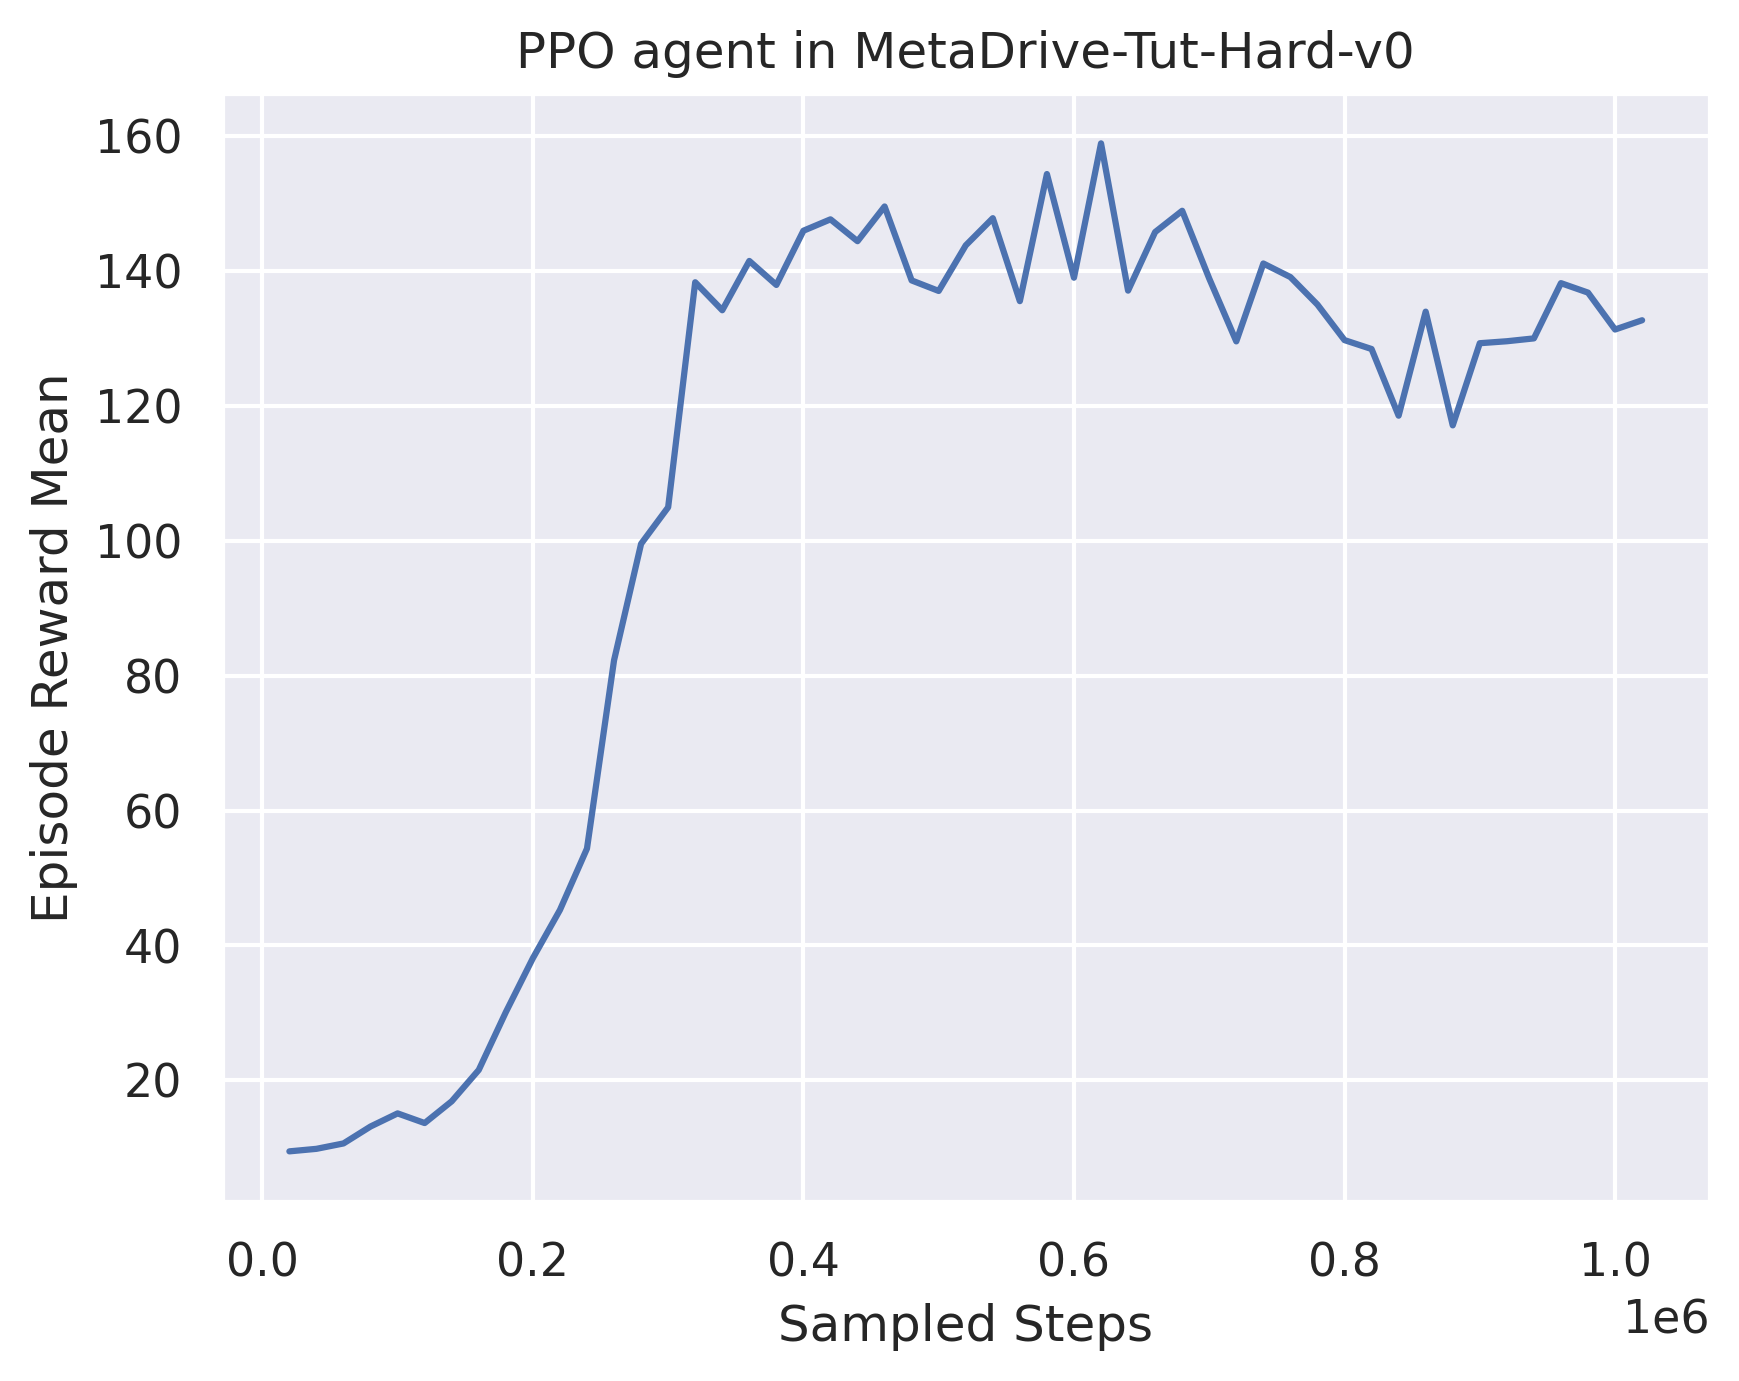

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ppo_progress = pd.read_csv("MetaDrive-Tut-Hard-v0/ppo/progress.csv")
plt.figure(dpi=300)
sns.set("notebook", "darkgrid")
ax = sns.lineplot(
    data=ppo_progress,
    x="total_steps",
    y="episode_reward"
)
ax.set_title("PPO agent in MetaDrive-Tut-Hard-v0")
ax.set_ylabel("Episode Reward Mean")
ax.set_xlabel("Sampled Steps")

ax.ticklabel_format(style='sci', scilimits=(0,0), axis='x')

plt.savefig('metadrive-hard-ppo.png', format='png', dpi=300, bbox_inches="tight")


### Demo 3.3: Evaluate PPO in MetaDrive

In [ ]:
!python eval_ppo.py \
  --env-id="MetaDrive-Tut-Hard-v0" \
  --log-dir="MetaDrive-Tut-Hard-v0/ppo"

/content/gdrive/MyDrive/cs260r/core
/content/gdrive/MyDrive/cs260r/core
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
Successfully registered MetaDrive environments:  ['MetaDrive-Tut-Easy-v0', 'MetaDrive-Tut-Hard-v0', 'MetaDrive-Tut-1Env-v0', 'MetaDrive-Tut-5Env-v0', 'MetaDrive-Tut-10Env-v0', 'MetaDrive-Tut-20Env-v0', 'MetaDrive-Tut-50Env-v0', 'MetaDrive-Tut-100Env-v0', 'MetaDrive-Tut-Test-v0']
/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment MetaDrive-Tut-Easy-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment MetaDrive-Tut-Hard-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ppo_eval = pd.read_csv("MetaDrive-Tut-Hard-v0/ppo/eval_results.csv")
print("PPO agent average reward: {}".format(ppo_eval.rewards.mean()))

PPO agent average reward: 121.7063032157254


### Demo 3.4: Visualize the performance of PPO in MetaDrive Hard Env.

You might have different maps in your visualization, that's expected.

In [ ]:
# Load the agent using PolicyAPI (easy to use interface to get policy)

from core.envs import make_envs
import gymnasium as gym
from vis import PPOPolicy, evaluate, animate
import pygame

env_name = "MetaDrive-Tut-Hard-v0"
policy = PPOPolicy(
    env_name,  # In order to get the observation shape
    num_envs=1,
    log_dir="MetaDrive-Tut-Hard-v0/ppo/",
    suffix="final"
)


# Render the learned behavior
# NOTE: The learned agent is marked by green color.
eval_reward, eval_info = evaluate(
    policy=policy,
    num_episodes=1,
    env_name=env_name,
    render="topdown",  # Visualize the behaviors in top-down view
    verbose=True
)

animate(eval_info["frames"])

print("PPO agent achieves {} return in MetaDrive Hard environment.".format(eval_reward))

/content/gdrive/My Drive/cs260r/core
/content/gdrive/My Drive/cs260r/core


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
[INFO] Environment: MetaDriveEnv
[INFO] MetaDrive version: 0.4.3
[INFO] Sensors: [lidar: Lidar(), side_detector: SideDetector(), lane_line_detector: LaneLineDetector()]
[INFO] Render Mode: none
[INFO] Horizon (Max steps per agent): 1000


Successfully registered MetaDrive environments:  ['MetaDrive-Tut-Easy-v0', 'MetaDrive-Tut-Hard-v0', 'MetaDrive-Tut-1Env-v0', 'MetaDrive-Tut-5Env-v0', 'MetaDrive-Tut-10Env-v0', 'MetaDrive-Tut-20Env-v0', 'MetaDrive-Tut-50Env-v0', 'MetaDrive-Tut-100Env-v0', 'MetaDrive-Tut-Test-v0']


[INFO] Environment: MetaDriveEnv
[INFO] MetaDrive version: 0.4.3
[INFO] Sensors: [lidar: Lidar(), side_detector: SideDetector(), lane_line_detector: LaneLineDetector()]
[INFO] Render Mode: none
[INFO] Horizon (Max steps per agent): 1000
[INFO] Assets version: 0.4.3
[INFO] Known Pipes: glxGraphicsPipe
[INFO] Start Scenario Index: 1000, Num Scenarios : 20


Successfully load weights from /content/gdrive/My Drive/cs260r/MetaDrive-Tut-Hard-v0/ppo/checkpoint-final.pkl!
Evaluating 1/1 episodes. We are in 1/1000 steps. Current episode reward: 0.008
Evaluating 1/1 episodes. We are in 51/1000 steps. Current episode reward: 29.992
Evaluating 1/1 episodes. We are in 101/1000 steps. Current episode reward: 96.854
Evaluating 1/1 episodes. We are in 151/1000 steps. Current episode reward: 177.373


This browser does not support the video tag.


PPO agent achieves 200.13437437971618 return in MetaDrive Hard environment.
